# **Logistic Regression**

In [ ]:
import pandas as pd
df=pd.read_csv('customer_data.csv')
print(df.head())
print(df.describe())
print(df.shape)
print(df.info)

   Age  Annual_Income  Spending_Score  Purchase
0   56          20237               1         0
1   46          35056              90         0
2   32         129548              14         0
3   25         126488              64         1
4   38         149415              38         0
              Age  Annual_Income  Spending_Score    Purchase
count  400.000000     400.000000      400.000000  400.000000
mean    39.295000   80859.982500       48.295000    0.397500
std     12.321425   39361.208098       28.700038    0.489994
min     18.000000   15404.000000        1.000000    0.000000
25%     29.000000   42940.000000       25.000000    0.000000
50%     41.000000   81121.500000       47.000000    0.000000
75%     50.000000  116683.250000       73.000000    1.000000
max     59.000000  149668.000000       99.000000    1.000000
(400, 4)
<bound method DataFrame.info of      Age  Annual_Income  Spending_Score  Purchase
0     56          20237               1         0
1     46          3505

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#preprocessing
X = df[['Age', 'Annual_Income', 'Spending_Score']]
y = df['Purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.8583333333333333
Precision: 0.8461538461538461
Recall: 0.75
F1 Score: 0.7951807228915663


# **SVM KNN and DECISION TREE**

In [ ]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))


SVM
Accuracy: 0.9333333333333333
Precision: 0.95
Recall: 0.8636363636363636
F1 Score: 0.9047619047619048


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("\nKNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))


KNN
Accuracy: 0.9583333333333334
Precision: 0.9534883720930233
Recall: 0.9318181818181818
F1 Score: 0.9425287356321839


In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\nDecision Tree (Gini)")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Decision Tree (Gini)
Accuracy: 0.975
Precision: 1.0
Recall: 0.9318181818181818
F1 Score: 0.9647058823529412


In [ ]:
y_pred_log_train = log_model.predict(X_train_scaled)
accuracy_log_train = accuracy_score(y_train, y_pred_log_train)

y_pred_svm_train = svm_model.predict(X_train_scaled)
accuracy_svm_train = accuracy_score(y_train, y_pred_svm_train)

y_pred_knn_train = knn_model.predict(X_train_scaled)
accuracy_knn_train = accuracy_score(y_train, y_pred_knn_train)

y_pred_dt_train = dt_model.predict(X_train)
accuracy_dt_train = accuracy_score(y_train, y_pred_dt_train)

comparative_accuracies = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'KNN', 'Decision Tree'],
    'Training Accuracy': [
        accuracy_log_train,
        accuracy_svm_train,
        accuracy_knn_train,
        accuracy_dt_train
    ],
    'Testing Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print("\nComparative Training and Testing Accuracies")
print(comparative_accuracies)


Comparative Training and Testing Accuracies
                 Model  Training Accuracy  Testing Accuracy
0  Logistic Regression           0.846429          0.858333
1                  SVM           0.982143          0.933333
2                  KNN           0.989286          0.958333
3        Decision Tree           1.000000          0.975000


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ]
})

print("\nComparative Results")
print(results)


Comparative Results
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.858333   0.846154  0.750000  0.795181
1                  SVM  0.933333   0.950000  0.863636  0.904762
2                  KNN  0.958333   0.953488  0.931818  0.942529
3        Decision Tree  0.975000   1.000000  0.931818  0.964706


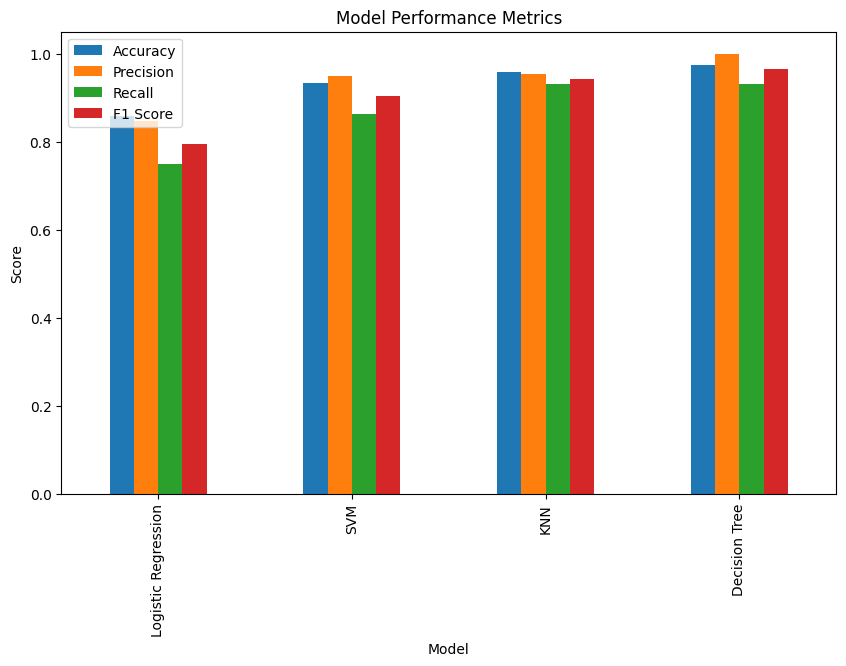

In [ ]:
#visualising using bar graph
results.set_index('Model', inplace=True)
results.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.show()

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

In [ ]:
X_vis = df[['Age', 'Spending_Score']]
y_vis = df['Purchase']

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42
)

scaler_vis = StandardScaler()
X_train_vis_scaled = scaler_vis.fit_transform(X_train_vis)
X_test_vis_scaled = scaler_vis.transform(X_test_vis)

In [ ]:
def plot_decision_boundary(model, X, y, title):
    X_set, y_set = X, y

    X1, X2 = np.meshgrid(
        np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.1),
        np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.1)
    )

    plt.contourf(X1, X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.3, cmap=ListedColormap(('red', 'green')))

    plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set,
                cmap=ListedColormap(('red', 'green')), edgecolor='k')

    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('Spending Score')
    plt.show()


Confusion Matrix - Logistic Regression:


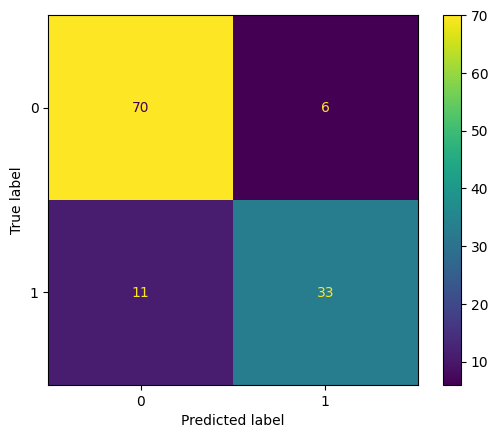

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(log_model, X_test_scaled, y_test)
print("\nConfusion Matrix - Logistic Regression:")
plt.show()


Confusion Matrix - SVM:


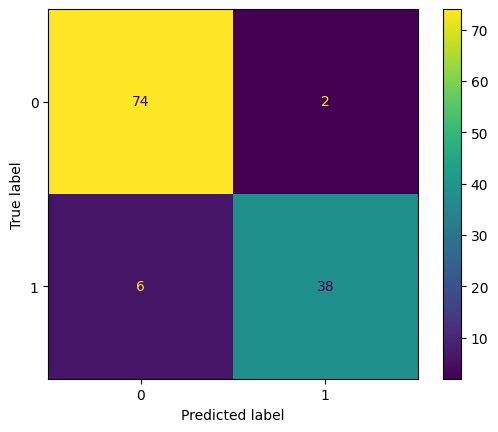

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_scaled, y_test)
print("\nConfusion Matrix - SVM:")
plt.show()


Confusion Matrix - KNN:


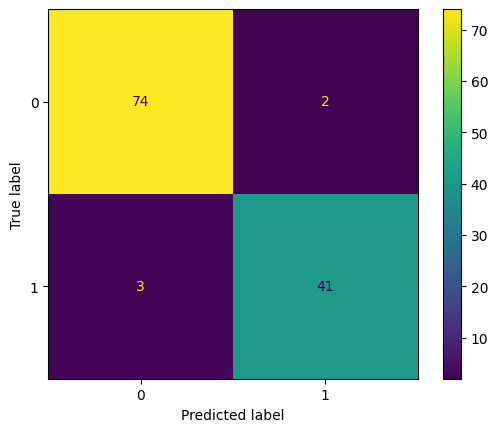

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(knn_model, X_test_scaled, y_test)
print("\nConfusion Matrix - KNN:")
plt.show()


Confusion Matrix - Decision Tree:


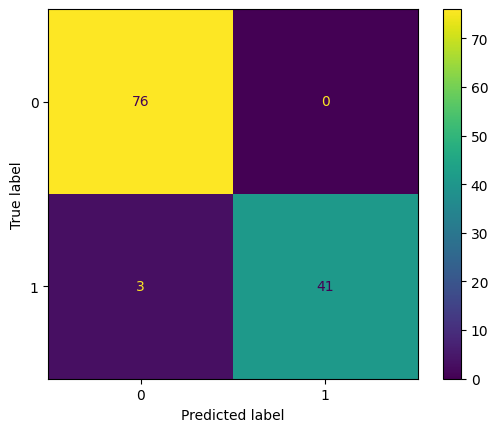

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test)
print("\nConfusion Matrix - Decision Tree:")
plt.show()

In [ ]:
#from sklearn.metrics show confusion matrix for all 4

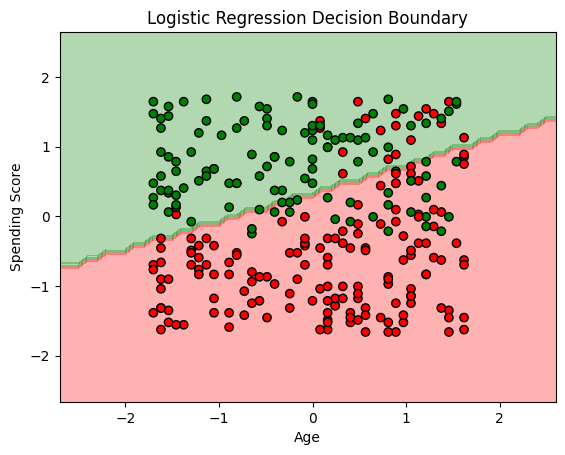

In [ ]:
log_vis = LogisticRegression()
log_vis.fit(X_train_vis_scaled, y_train_vis)

plot_decision_boundary(log_vis, X_train_vis_scaled, y_train_vis,
                       "Logistic Regression Decision Boundary")

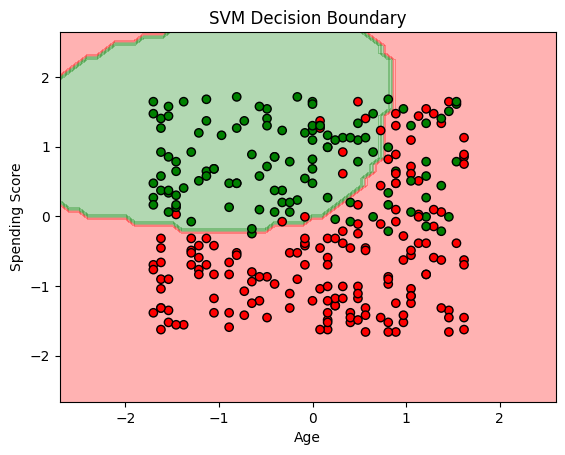

In [ ]:
svm_vis = SVC(kernel='rbf')
svm_vis.fit(X_train_vis_scaled, y_train_vis)

plot_decision_boundary(svm_vis, X_train_vis_scaled, y_train_vis,
                       "SVM Decision Boundary")

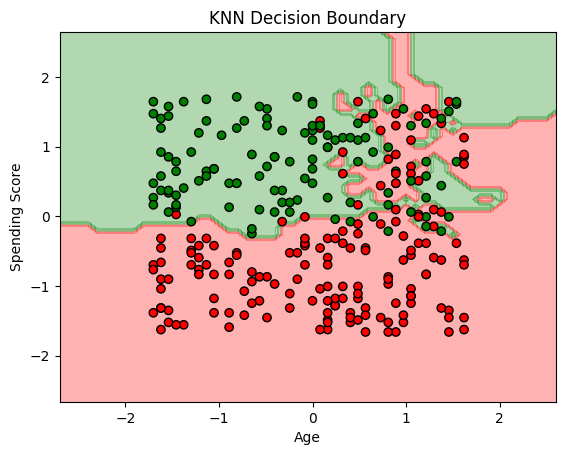

In [ ]:
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_train_vis_scaled, y_train_vis)

plot_decision_boundary(knn_vis, X_train_vis_scaled, y_train_vis,
                       "KNN Decision Boundary")

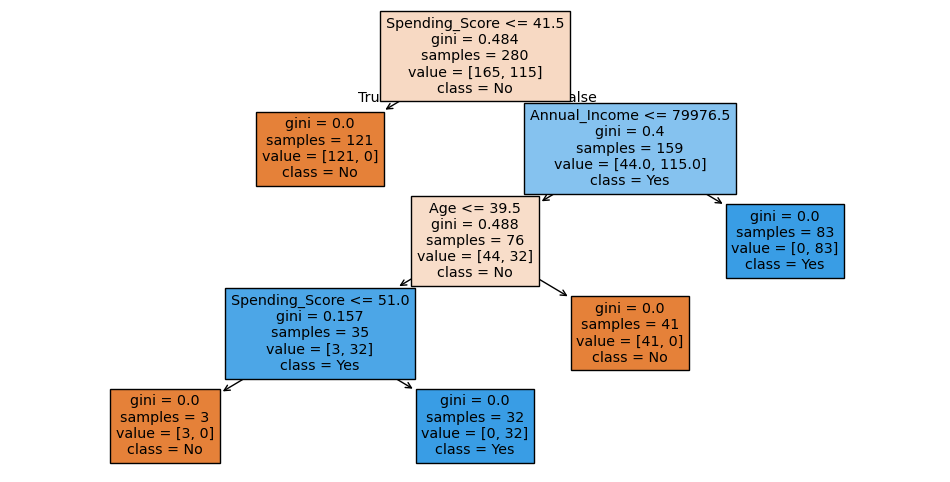

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(dt_model, feature_names=X.columns,
          class_names=['No', 'Yes'], filled=True)
plt.show()